# 2.6 — Exploratory Data Analysis (EDA)

EDA is what you do before any modelling. You look at the data from every angle to understand its shape, spot problems, find patterns, and decide what cleaning and engineering it needs.

> **Why it matters:** Without EDA you throw raw data at a model, get poor results, and have no idea why. With EDA you know exactly what the data needs before writing a single model line.

### EDA connects everything from 2.1–2.5:
- Missing values (2.1) — found during EDA
- Outliers (2.2) — spotted in boxplots and describe()
- Encoding needs (2.3) — identified by checking dtypes
- Scaling needs (2.4) — identified by checking ranges
- Feature ideas (2.5) — inspired by groupby and correlation findings

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Titanic — no download needed, seaborn has it built in
df = sns.load_dataset('titanic')
print("Dataset loaded:", df.shape)
df.head()

Dataset loaded: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Step 1 — Shape & Structure

In [3]:
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (891, 15)

Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']


In [4]:
# Data types and null counts — most important first command
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB


In [5]:
# Missing values
missing = df.isnull().sum().sort_values(ascending=False)
missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
pd.DataFrame({'count': missing, 'percent': missing_pct.round(1)}).head(10)

,count,percent
deck,688,77.2
age,177,19.9
embarked,2,0.2
embark_town,2,0.2
survived,0,0.0
pclass,0,0.0
sex,0,0.0
sibsp,0,0.0
parch,0,0.0
fare,0,0.0


In [6]:
# Duplicates
print("Duplicate rows:", df.duplicated().sum())

# Unique values per column
df.nunique().sort_values()

Duplicate rows: 107


survived         2
sex              2
adult_male       2
alive            2
alone            2
pclass           3
embarked         3
class            3
who              3
embark_town      3
sibsp            7
parch            7
deck             7
age             88
fare           248
dtype: int64

## Step 2 — Statistics & Distributions

In [7]:
# Summary stats for numeric columns
df.describe().round(2)

,survived,pclass,age,sibsp,parch,fare
count,891.00,891.00,714.00,891.00,891.00,891.00
mean,0.38,2.31,29.70,0.52,0.38,32.20
std,0.49,0.84,14.53,1.10,0.81,49.69
min,0.00,1.00,0.42,0.00,0.00,0.00
25%,0.00,2.00,20.12,0.00,0.00,7.91
50%,0.00,3.00,28.00,0.00,0.00,14.45
75%,1.00,3.00,38.00,1.00,0.00,31.00
max,1.00,3.00,80.00,8.00,6.00,512.33


In [8]:
# Skewness — high value means skewed
df.skew(numeric_only=True).sort_values(ascending=False).round(2)

fare          4.79
sibsp         3.70
parch         2.75
survived      0.48
age           0.39
adult_male   -0.42
alone        -0.42
pclass       -0.63
dtype: float64

In [9]:
# Class imbalance — how balanced is the target?
print("Survival counts:")
print(df['survived'].value_counts())
print("\nSurvival rate:")
print((df['survived'].value_counts(normalize=True) * 100).round(1))

Survival counts:
survived
0    549
1    342
Name: count, dtype: int64

Survival rate:
survived
0    61.6
1    38.4
Name: proportion, dtype: float64


## Step 3 — Visualisations

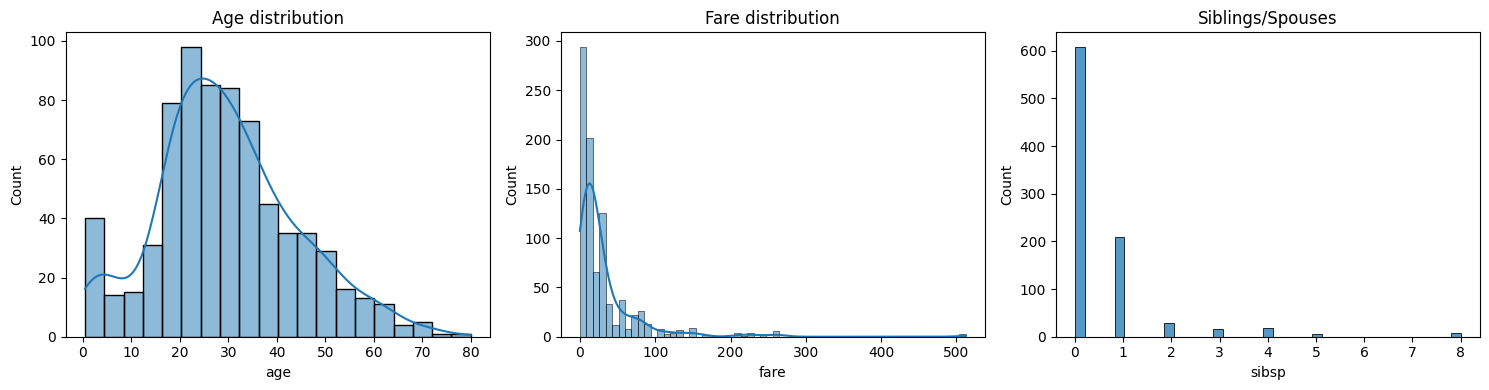

In [10]:
# Histograms for numeric columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(df['age'].dropna(), kde=True, ax=axes[0])
axes[0].set_title('Age distribution')

sns.histplot(df['fare'], kde=True, ax=axes[1])
axes[1].set_title('Fare distribution')

sns.histplot(df['sibsp'], kde=False, ax=axes[2])
axes[2].set_title('Siblings/Spouses')

plt.tight_layout()
plt.show()

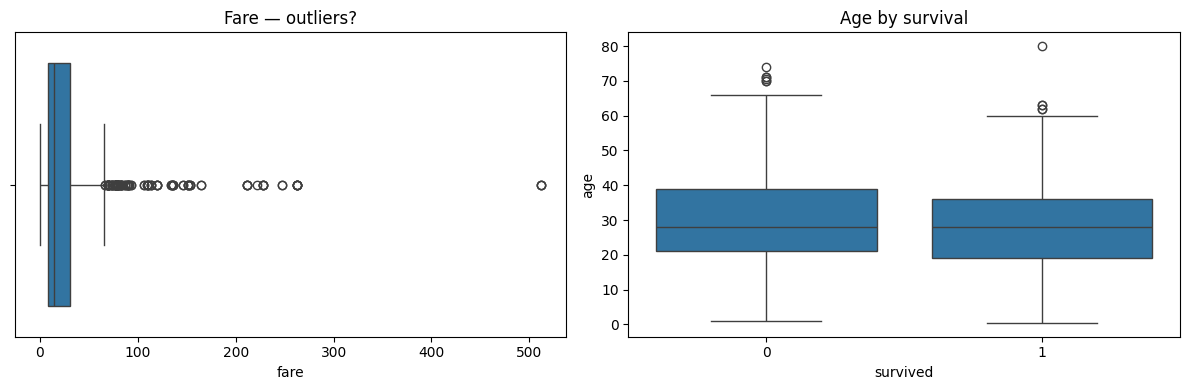

In [11]:
# Boxplots — spot outliers
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(x=df['fare'], ax=axes[0])
axes[0].set_title('Fare — outliers?')

sns.boxplot(x='survived', y='age', data=df, ax=axes[1])
axes[1].set_title('Age by survival')

plt.tight_layout()
plt.show()

In [ ]:
# Countplots for categorical columns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(x='sex', hue='survived', data=df, ax=axes[0])
axes[0].set_title('Sex vs Survived')

sns.countplot(x='pclass', hue='survived', data=df, ax=axes[1])
axes[1].set_title('Pclass vs Survived')

sns.countplot(x='embarked', hue='survived', data=df, ax=axes[2])
axes[2].set_title('Embarked vs Survived')

plt.tight_layout()
plt.show()

## Step 4 — Correlations & Relationships

In [12]:
# Correlation with target
df.corr(numeric_only=True)['survived'].sort_values().round(3)

adult_male   -0.557
pclass       -0.338
alone        -0.203
age          -0.077
sibsp        -0.035
parch         0.082
fare          0.257
survived      1.000
Name: survived, dtype: float64

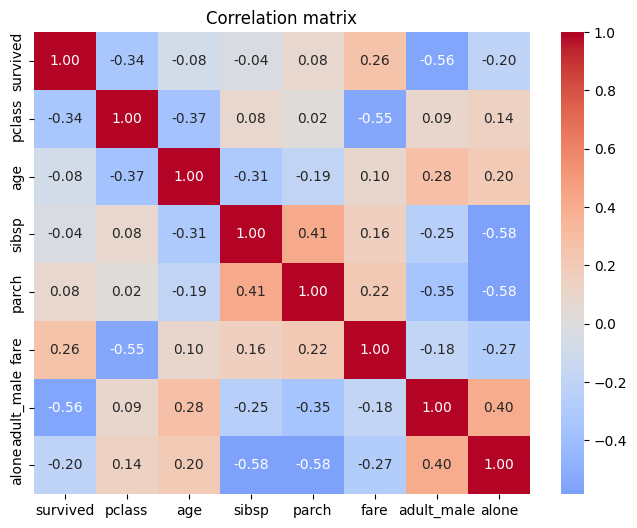

In [13]:
# Correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(
    df.corr(numeric_only=True),
    annot=True, fmt='.2f', cmap='coolwarm', center=0
)
plt.title('Correlation matrix')
plt.show()

In [14]:
# Groupby — survival rate by categorical features
print("Survival rate by sex:")
print(df.groupby('sex')['survived'].mean().round(2))

print("\nSurvival rate by pclass:")
print(df.groupby('pclass')['survived'].mean().round(2))

print("\nSurvival rate by embarked:")
print(df.groupby('embarked')['survived'].mean().round(2))

Survival rate by sex:
sex
female    0.74
male      0.19
Name: survived, dtype: float64

Survival rate by pclass:
pclass
1    0.63
2    0.47
3    0.24
Name: survived, dtype: float64

Survival rate by embarked:
embarked
C    0.55
Q    0.39
S    0.34
Name: survived, dtype: float64


## Step 5 — EDA Findings & Conclusions

Write your observations here after running the cells above.

**Missing values:**
- Age: ~20% missing → fill with median
- Deck/Cabin: ~77% missing → drop column
- Embarked: 2 missing → fill with mode

**Outliers:**
- Fare has extreme outliers (max 512 vs 75th percentile 31) → cap or log transform

**Class imbalance:**
- 62% did not survive, 38% survived → accuracy alone is misleading

**Key patterns found:**
- Women survived 74% vs men 19% → sex is a strong feature
- 1st class survived 63% vs 3rd class 24% → pclass is important
- Higher fare = higher survival → fare correlates with pclass

**Encoding needed:**
- sex → label encode (binary)
- embarked → one-hot encode
- pclass → already numeric, keep as is

**Feature engineering ideas:**
- family_size = sibsp + parch + 1
- is_alone = 1 if family_size == 1
- title extracted from name (Mr, Mrs, Miss, Master)

## The 14-Step EDA Checklist

Run this on every new dataset:

| # | Command | What it tells you |
|---|---------|------------------|
| 1 | `df.shape` | Rows and columns |
| 2 | `df.info()` | Types and nulls |
| 3 | `df.isnull().sum()` | Missing value counts |
| 4 | `df.duplicated().sum()` | Duplicate rows |
| 5 | `df.describe()` | Stats — check min/max for outliers |
| 6 | `df.skew()` | Which columns are skewed |
| 7 | `df['target'].value_counts(normalize=True)` | Class imbalance |
| 8 | `df.nunique()` | Which columns are categorical |
| 9 | Histograms | Shape of distributions |
| 10 | Boxplots | Outliers visually |
| 11 | Countplots | Frequency of categories |
| 12 | `df.corr()['target']` | Features related to target |
| 13 | `groupby('col')['target'].mean()` | Category vs target |
| 14 | Correlation heatmap | Multicollinearity |

## Practice Task

Run the full 14-step checklist on the Titanic dataset and write your own observations in a markdown cell.

In [ ]:
# YOUR EDA HERE — work through all 14 steps
# Write observations as markdown cells below each finding